# World Cup 2022 Final — demo

Thin walkthrough of `football_data`: look up the Argentina vs France final, print shot/pass summaries, draw the maps.

Logic lives in `src/football_data/` (`data.py`, `analysis.py`, `viz.py`). This notebook only calls those functions.

In [1]:
from pathlib import Path

from football_data import (
    get_pass_map,
    get_shot_map,
    load_events,
    pass_completion,
    shot_summary,
    shots_table,
    world_cup_2022_final,
)

OUTPUTS = Path("outputs")
if not OUTPUTS.exists():
    OUTPUTS = Path("..") / "outputs"

match = world_cup_2022_final()
match

MatchInfo(match_id=3869685, home_team='Argentina', away_team='France', home_score=3, away_score=3, match_date='2022-12-18', competition_stage='Final')

## Shots

`shots_table` unpacks locations and StatsBomb xG into flat columns (usable later as JSON). Penalty-shootout attempts are included, so goals exceed the 3–3 scoreline.

In [2]:
events = load_events(match.match_id)
shots = shots_table(events)
shot_summary(shots)

,team,shots,goals,xg
0,Argentina,24,7,5.892306
1,France,14,5,5.406618


Saved ..\outputs\wc2022_final_3869685_shots.png


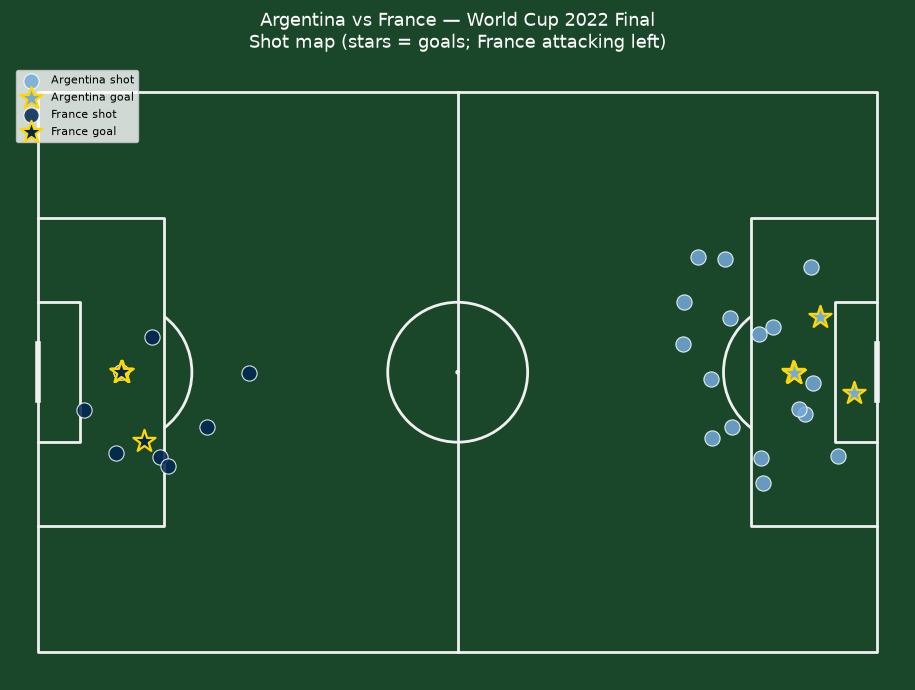

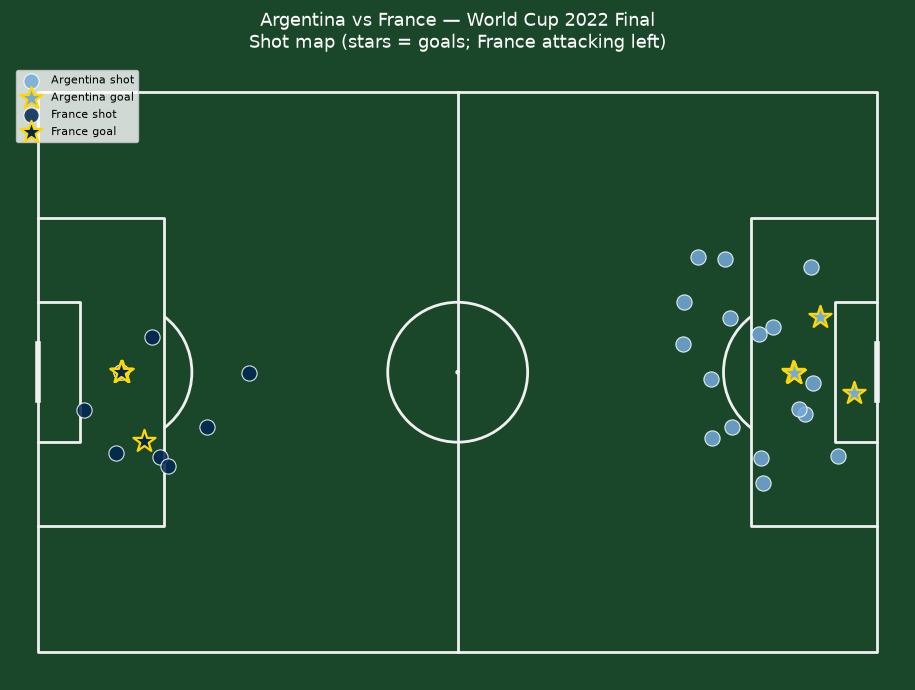

In [3]:
shot_path = OUTPUTS / f"wc2022_final_{match.match_id}_shots.png"
fig = get_shot_map(
    match,
    title=f"{match.home_team} vs {match.away_team} — World Cup 2022 Final\nShot map (stars = goals; {match.away_team} attacking left)",
    save_path=shot_path,
)
print(f"Saved {shot_path}")
fig

## Messi's completed passes

In [4]:
pass_stats = pass_completion(events, "Messi")
pass_stats

{'player': 'Lionel Andrés Messi Cuccittini',
 'attempted': 60,
 'completed': 49,
 'completion_pct': 81.7}

Saved ..\outputs\wc2022_final_3869685_messi_passes.png


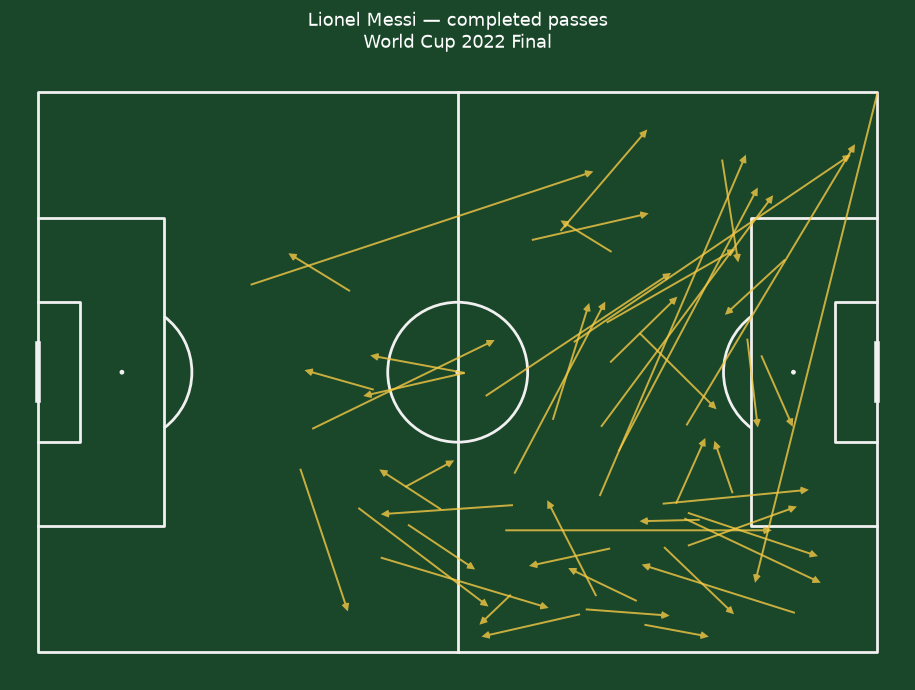

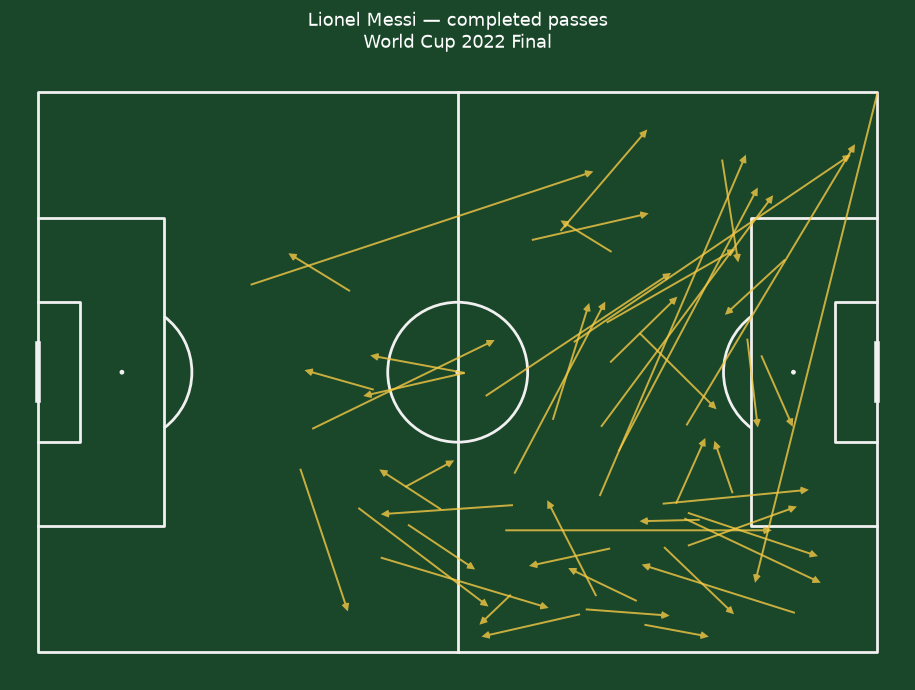

In [5]:
pass_path = OUTPUTS / f"wc2022_final_{match.match_id}_messi_passes.png"
fig = get_pass_map(
    match,
    "Messi",
    title="Lionel Messi — completed passes\nWorld Cup 2022 Final",
    save_path=pass_path,
)
print(f"Saved {pass_path}")
fig